# 可选实验 - 简单神经网络
在本实验中，我们将使用Numpy构建一个小型神经网络。它将与你在Tensorflow中实现的"咖啡烘焙"网络相同。
   <center> <img  src="./images/C2_W1_CoffeeRoasting.png" width="400" />   <center/>


In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
import tensorflow as tf
from lab_utils_common import dlc, sigmoid
from lab_coffee_utils import load_coffee_data, plt_roast, plt_prob, plt_layer, plt_network, plt_output_unit
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

I0000 00:00:1781367269.621863  149455 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781367269.681016  149455 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781367271.452344  149455 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 数据集
这与前一个实验的数据集相同。

In [2]:
X,Y = load_coffee_data();
print(X.shape, Y.shape)

(200, 2) (200, 1)


让我们在下面绘制咖啡烘焙数据。两个特征分别是温度（摄氏度）和时间（分钟）。[在家烘焙咖啡](https://www.merchantsofgreencoffee.com/how-to-roast-green-coffee-in-your-oven/)建议时间最好保持在12到15分钟之间，温度应在175到260摄氏度之间。当然，随着温度升高，时间应该缩短。

/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38047 (\N{CJK UNIFIED IDEOGRAPH-949F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21654 (\N{CJK UNIFIED IDEOGRAPH-5496}) m

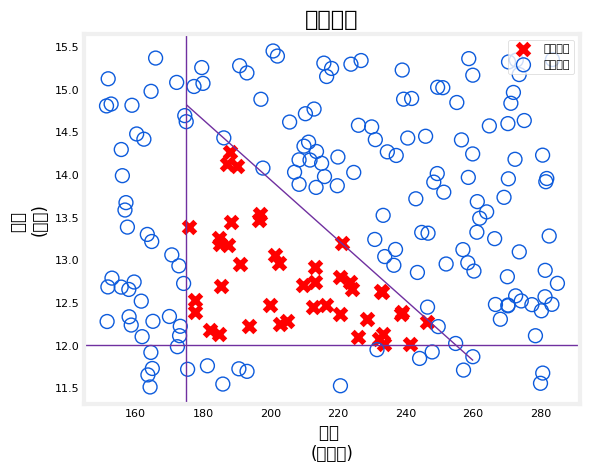

In [3]:
plt_roast(X,Y)

### 归一化数据
为了与前一个实验保持一致，我们将对数据进行归一化。更多细节请参考该实验。

In [4]:
print(f"Temperature Max, Min pre normalization: {np.max(X[:,0]):0.2f}, {np.min(X[:,0]):0.2f}")
print(f"Duration    Max, Min pre normalization: {np.max(X[:,1]):0.2f}, {np.min(X[:,1]):0.2f}")
norm_l = tf.keras.layers.Normalization(axis=-1)
norm_l.adapt(X)  # 学习均值、方差
Xn = norm_l(X)
print(f"Temperature Max, Min post normalization: {np.max(Xn[:,0]):0.2f}, {np.min(Xn[:,0]):0.2f}")
print(f"Duration    Max, Min post normalization: {np.max(Xn[:,1]):0.2f}, {np.min(Xn[:,1]):0.2f}")

Temperature Max, Min pre normalization: 284.99, 151.32
Duration    Max, Min pre normalization: 15.45, 11.51
Temperature Max, Min post normalization: 1.66, -1.69
Duration    Max, Min post normalization: 1.79, -1.70


W0000 00:00:1781367274.472963  149455 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Numpy模型（NumPy中的前向传播）
<center> <img  src="./images/C2_W1_RoastingNetwork.PNG" width="200" />   <center/>  
让我们构建讲座中描述的"咖啡烘焙网络"。有两个带有sigmoid激活函数的层。

如讲座中所述，可以使用NumPy构建自己的密集层。然后可以利用它来构建多层神经网络。 

<img src="images/C2_W1_dense3.png" width="600" height="450">

在第一个可选实验中，你在NumPy和Tensorflow中构建了一个神经元，并注意到它们的相似性。一个层只是包含多个神经元/单元。如讲座中所述，可以使用for循环访问层中的每个单元（`j`），并对该单元的权重（`W[:,j]`）执行点积，并对单元的偏置（`b[j]`）求和以形成`z`。然后可以对该结果应用激活函数`g(z)`。让我们在下面尝试构建一个"密集层"子程序。

首先，你将定义激活函数`g()`。你将使用`sigmoid()`函数，该函数已经在notebook外部的`lab_utils_common.py`文件中为你实现。

In [5]:
# 定义激活函数
g = sigmoid

接下来，你将定义`my_dense()`函数，该函数计算密集层的激活值。

In [6]:
def my_dense(a_in, W, b):
    """
    计算密集层
    参数:
      a_in (ndarray (n, )) : 数据，1个样本 
      W    (ndarray (n,j)) : 权重矩阵，每个单元n个特征，j个单元
      b    (ndarray (j, )) : 偏置向量，j个单元  
    返回
      a_out (ndarray (j,))  : j个单元
    """
    units = W.shape[1]
    a_out = np.zeros(units)
    for j in range(units):               
        w = W[:,j]                                    
        z = np.dot(w, a_in) + b[j]         
        a_out[j] = g(z)               
    return(a_out)

*注意：你也可以将上面的函数实现为接受`g`作为额外参数（例如`my_dense(a_in, W, b, g)`）。但在本notebook中，你将只使用一种类型的激活函数（即sigmoid），所以将其设为常量并在函数外部定义是可以的。这就是你在上面的代码中所做的，它使下一个代码单元中的函数调用更简单。请记住，将其作为参数传递也是可以接受的实现方式。你会在本周的作业中看到这一点。*

以下单元使用上面的`my_dense`子程序构建了一个两层神经网络。

In [7]:
def my_sequential(x, W1, b1, W2, b2):
    a1 = my_dense(x,  W1, b1)
    a2 = my_dense(a1, W2, b2)
    return(a2)

我们可以从前一个Tensorflow实验中复制训练好的权重和偏置。

In [8]:
W1_tmp = np.array( [[-8.93,  0.29, 12.9 ], [-0.1,  -7.32, 10.81]] )
b1_tmp = np.array( [-9.82, -9.28,  0.96] )
W2_tmp = np.array( [[-31.18], [-27.59], [-32.56]] )
b2_tmp = np.array( [15.41] )

### 预测
<img align="left" src="./images/C2_W1_RoastingDecision.PNG"     style=" width:380px; padding: 10px 20px; " >

一旦你有了训练好的模型，就可以用它进行预测。回想一下，我们模型的输出是一个概率。在这种情况下，是良好烘焙的概率。为了做出决策，必须将概率与阈值进行比较。在这种情况下，我们将使用0.5。

让我们从编写一个类似于Tensorflow的`model.predict()`的例程开始。这将接受一个矩阵$X$，其中所有$m$个样本在行中，并通过运行模型进行预测。

In [9]:
def my_predict(X, W1, b1, W2, b2):
    m = X.shape[0]
    p = np.zeros((m,1))
    for i in range(m):
        p[i,0] = my_sequential(X[i], W1, b1, W2, b2).item()
    return(p)

我们可以在两个样本上尝试这个例程：

In [10]:
X_tst = np.array([
    [200,13.9],  # 正面样本
    [200,17]])   # 负面样本
X_tstn = norm_l(X_tst).numpy()  # 记得归一化，并转为numpy数组
predictions = my_predict(X_tstn, W1_tmp, b1_tmp, W2_tmp, b2_tmp)

要将概率转换为决策，我们应用阈值：

In [11]:
yhat = np.zeros_like(predictions)
for i in range(len(predictions)):
    if predictions[i] >= 0.5:
        yhat[i] = 1
    else:
        yhat[i] = 0
print(f"decisions = \n{yhat}")

decisions = 
[[1.]
 [0.]]


可以用更简洁的方式实现：

In [12]:
yhat = (predictions >= 0.5).astype(int)
print(f"decisions = \n{yhat}")

decisions = 
[[1]
 [0]]


## 网络函数

此图展示了整个网络的运行情况，与前一个实验中Tensorflow的结果相同。
左图是最后一层的原始输出，用蓝色阴影表示。这叠加在由X和O表示的训练数据上。   
右图是网络在决策阈值后的输出。这里的X和O对应于网络做出的决策。  

/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 38047 (\N{CJK UNIFIED IDEOGRAPH-949F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 32593 (\N{CJK UNIFIED IDEOGRAPH-7F51}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/

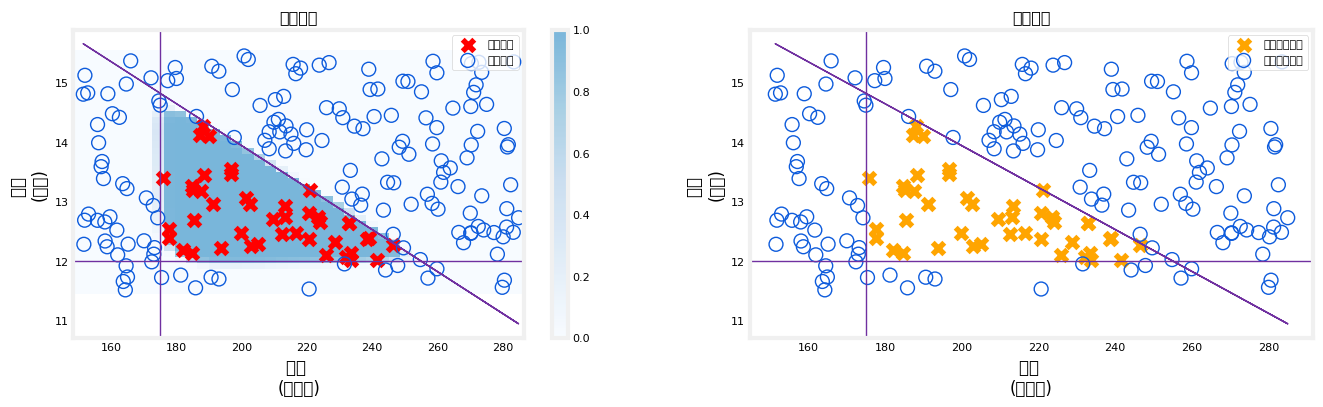

In [13]:
netf= lambda x : my_predict(norm_l(x),W1_tmp, b1_tmp, W2_tmp, b2_tmp)
plt_network(X,Y,netf)

## 恭喜！
你已经在NumPy中构建了一个小型神经网络。 
希望本实验揭示了构成神经网络层的相当简单和熟悉的函数。